In [25]:
import sys
import os
import pandas as pd

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork
from src.metrics import Rejection, FalseRejection, rv_coefficient
from src.methods import RVPermutationTest
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
import re
from src.plot_functions import plot_grid, plot_with_bands
import ast
import numpy as np

In [26]:
results = pd.read_csv("simulation_results_20260211_0826.csv")

In [27]:
# nsim = 100
# n = [50, 100, 150, 200]
# k = [3]
# rho = [0.5]
# alpha = [0.05]
# marginals = [stats.norm]
# edge_var = [1, 3]
# method = [FitIndependent]

# npermutations = [500]
# metrics = [ComputeAll()]
# approximation = ["F-distr"]

# setup = [
#     (partial(GaussianNetwork, copula_model='gaussian', rho=0), MLE_gaussian),
#     (partial(GaussianNetwork, copula_model='gaussian', rho=0.5), MLE_gaussian),
#     (partial(GaussianNetwork, copula_model='frank', rho=0.5), MLE_gaussian),
#     (partial(GaussianNetwork, copula_model='clayton', rho=0.5), MLE_gaussian),
#     (partial(GaussianNetwork, copula_model='mixture_uniform', weights=[0.5, 0.5], correlations=[0.98, -0.98], rho=0.5), MLE_gaussian),
#     (partial(GaussianNetwork, copula_model='mixture_uniform', weights=[0.5, 0.5], correlations=[0.95, 0.95], rho=0.5), MLE_gaussian),

#     (partial(BernoulliNetwork, copula_model='gaussian', rho=0), MLE_gaussian),
#     (partial(BernoulliNetwork, copula_model='gaussian', rho=0.5), MLE_gaussian),
#     (partial(BernoulliNetwork, copula_model='frank', rho=0.5), MLE_gaussian),
#     (partial(BernoulliNetwork, copula_model='clayton', rho=0.5), MLE_gaussian),
#     (partial(BernoulliNetwork, copula_model='mixture_uniform', weights=[0.5, 0.5], correlations=[0.98, -0.98], rho=0.5), MLE_gaussian),
#     (partial(BernoulliNetwork, copula_model='mixture_uniform', weights=[0.5, 0.5], correlations=[0.95, 0.95], rho=0.5), MLE_gaussian),
# ]

In [28]:
results["rho"] = results["args"].apply(
    lambda x: re.search(r"'rho':\s*(\d+\.?\d*)", x).group(1)
)

In [29]:
results["ComputeAll"] = results["ComputeAll"].apply(
    lambda x: ast.literal_eval(re.sub(r"np\.float64\(([^)]+)\)", r"\1", x))
)

results['RelativeFrobeniusNorm_x'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_x', np.nan))
results['RelativeFrobeniusNorm_z'] = results['ComputeAll'].apply(lambda x: x.get('RelativeFrobeniusNorm_z', np.nan))

In [30]:
results['dgp_name'] = results['dgp'].apply(lambda x: x.split('_')[0])
results['copula_type'] = results['dgp'].apply(lambda x: x.split('_')[1])

### Defining different aggregations

In [31]:
# based on dgp
results_gaussian = results[(results["dgp_name"] == "GaussianNetwork")].copy()
results_bernoulli = results[(results["dgp_name"] == "BernoulliNetwork")].copy()

In [32]:
# based on rho + dgp
results_null_gaussian = results_gaussian[(results_gaussian["rho"] == "0")].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian["rho"] == "0.5")].copy()
results_alt_001_gaussian = results_gaussian[
    (results_gaussian["rho"] == "0.01")
].copy()
results_alt_01_gaussian = results_gaussian[(results_gaussian["rho"] == "0.1")].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli["rho"] == "0")].copy()
results_alt_05_bernoulli = results_bernoulli[
    (results_bernoulli["rho"] == "0.5")
].copy()
results_alt_001_bernoulli = results_bernoulli[
    (results_bernoulli["rho"] == "0.01")
].copy()
results_alt_01_bernoulli = results_bernoulli[
    (results_bernoulli["rho"] == "0.1")
].copy()

In [35]:
agg_null_gaussian = aggregate_results(results_null_gaussian, 
                                      y_axis="RelativeFrobeniusNorm_x",
                                      x_axis="n",
                                      factors=["edge_var", "k", "copula_type"])

agg_alt_05_gaussian = aggregate_results(results_alt_05_gaussian, 
                                        y_axis="RelativeFrobeniusNorm_x",
                                        x_axis="n",
                                        factors=["edge_var", "k", "copula_type"])

agg_alt_05_bernoulli = aggregate_results(results_alt_05_bernoulli, 
                                         y_axis="RelativeFrobeniusNorm_x",
                                         x_axis="n",
                                         factors=["edge_var", "k", "copula_type"])


## Plots

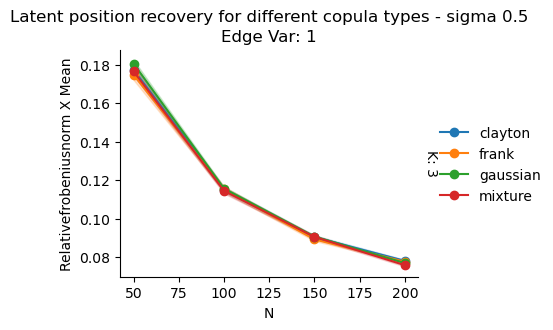

In [34]:
plot_grid(
    grouped_stats=agg_alt_05_gaussian,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["copula_type", "edge_var", "k"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=False,
    title="Latent position recovery for different copula types - sigma 0.5",
)

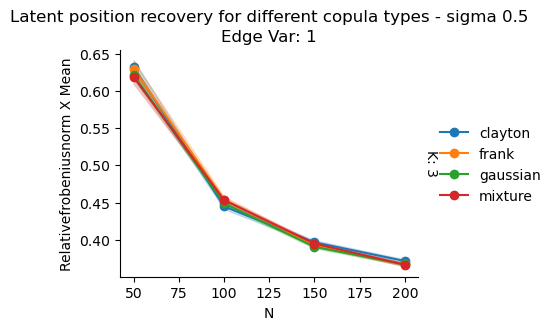

In [36]:
plot_grid(
    grouped_stats=agg_alt_05_bernoulli,
    plotting_function=plot_with_bands,
    x_axis="n",
    y_axis="RelativeFrobeniusNorm_x_mean",
    factors=["copula_type", "edge_var", "k"],
    height=3,
    se_bands="RelativeFrobeniusNorm_x_sem",
    share_x=True,
    share_y=False,
    title="Latent position recovery for different copula types - sigma 0.5",
)